# Inference Demo

In [1]:
%cd ..
import re
import os
from PIL import Image
from models.navidriveVLM import NaviDriveVLM
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

/home/ximeng/Documents/NaviDrive


/home/ximeng/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Model

In [2]:
driver_model_id = "Ximeng0831/NaviDrive-Qwen3-VL-2B-SFT" # load from huggingface
model = NaviDriveVLM(driver_model_id = driver_model_id)

Loading weights: 100%|██████████| 625/625 [00:00<00:00, 1226.94it/s, Materializing param=model.visual.pos_embed.weight]                                


## Load Dataset

In [3]:
sample_index = 637 # Available: [41, 100, 120, 323, 558, 637, 1483]

In [4]:
ds = load_dataset("Ximeng0831/NaviDrive-Reasoning", "qwen_32b", split="validation")
data = ds[sample_index]

In [5]:
# Load images: demo figures are stored in ./figures
camera_files = ["CAM_BACK", "CAM_BACK_LEFT", "CAM_FRONT_LEFT", "CAM_FRONT", "CAM_FRONT_RIGHT", "CAM_BACK_RIGHT"]
img_folder = f"figures/{sample_index}"
images = []
for filename in camera_files:
    filename = f"{filename}.jpg"
    img_path = os.path.join(img_folder, filename)
    img = Image.open(img_path).convert('RGB')
    images.append(img)

In [6]:
def filter_to_xy_str(original_str):
    pattern = r"\(([^)]+)\)"
    matches = re.findall(pattern, original_str)
    return ", ".join([f"({p.split(',')[0].strip()}, {p.split(',')[1].strip()})" if len(p.split(',')) > 2 else f"({p})" for p in matches])

## Prompts

In [7]:
ego_status_prompt = (
    "Current Dynamics:\n"
    f"- Velocity: {data['vel_val']:.2f} m/s\n"
    f"- Yaw Rate: {data['yr_val']:.2f} rad/s\n"
    f"- Acceleration (Longitudinal x, Lateral y): {data['acc_val']}\n"
    f"Past Trajectory (2Hz): {filter_to_xy_str(data['wp_past'])}\n"
    f"High-level Command: {data['command']}\n\n"
)

In [8]:
navi_user_prompt = (
                    "Inputs: 6 images (Full Surround View) and Ego-Vehicle Status.\n"
                    "1:BACK, 2:BACK_LEFT, 3:FRONT_LEFT, 4:FRONT, 5:FRONT_RIGHT, 6:BACK_RIGHT,.\n"
                    f"{ego_status_prompt}"
                    "Task: Analyze the current situation and provide the safest next action with reasons."
                    )

In [9]:
driver_user_prompt = (
                    f"{ego_status_prompt}"
                    "Predict the next 12 waypoints: (x1, y1), (x2, y2), ..., (x12, y12)."
                    )

## Run the Model

In [10]:
reason, all_pred_waypoints = model(navi_user_prompt, driver_user_prompt, images)

## Print the Results

In [11]:
print(reason)

Perception: The vehicle is moving forward on a wet urban street with moderate traffic. Rain is reducing visibility and increasing road slickness. Traffic lights and pedestrian crosswalks are visible ahead. No immediate obstacles or pedestrians are detected in the immediate vicinity.

Action: Maintain current trajectory and continue moving straight. Apply gentle braking to slow down slightly due to wet conditions.

Reasoning: The road surface is wet, which increases braking distance and reduces traction. Maintaining a steady speed and reducing longitudinal acceleration helps prevent skidding or hydroplaning. The lane markings and road signs are visible, indicating no need to deviate from the current path.


In [12]:
for i in range(len(all_pred_waypoints)):
    print(f"Waypoint {i+1}: {all_pred_waypoints[i]}")

Waypoint 1: [[4.26, -0.03], [8.5, -0.06], [12.72, -0.09], [16.92, -0.12], [21.11, -0.15], [25.29, -0.17], [29.47, -0.21], [33.66, -0.24], [37.82, -0.28], [41.96, -0.32], [46.15, -0.35], [50.32, -0.38]]
Waypoint 2: [[4.26, -0.02], [8.51, -0.03], [12.76, -0.04], [17.05, -0.03], [21.33, -0.03], [25.65, -0.01], [29.99, 0.0], [34.31, 0.01], [38.63, 0.02], [42.93, 0.01], [47.23, -0.02], [51.52, -0.05]]
Waypoint 3: [[4.27, -0.03], [8.56, -0.07], [12.83, -0.12], [17.09, -0.19], [21.35, -0.27], [25.59, -0.36], [29.83, -0.44], [34.05, -0.53], [38.27, -0.61], [42.5, -0.69], [46.65, -0.77], [50.77, -0.85]]
Waypoint 4: [[4.3, -0.01], [8.66, -0.03], [13.06, -0.04], [17.5, -0.06], [21.96, -0.09], [26.45, -0.11], [30.98, -0.13], [35.55, -0.15], [40.12, -0.17], [44.75, -0.18], [49.43, -0.19], [54.12, -0.19]]
Waypoint 5: [[4.25, -0.02], [8.49, -0.05], [12.65, -0.09], [16.73, -0.15], [20.78, -0.21], [24.8, -0.26], [28.79, -0.31], [32.75, -0.38], [36.67, -0.43], [40.5, -0.49], [44.26, -0.54], [48.0, -0.59

In [13]:
print("Ground Truth: ", filter_to_xy_str(data['wp_future']))

Ground Truth:  (4.27, -0.03), (8.63, -0.06), (13.07, -0.09), (17.49, -0.10), (21.95, -0.11), (26.37, -0.13), (30.82, -0.14), (35.28, -0.13), (39.72, -0.13), (44.17, -0.15), (48.80, -0.16), (53.32, -0.16)


## Visualization

In [14]:
def plot_gt_and_pred(gt_str, pred_wp=None):
    pattern = r"\(([-+]?\d*\.?\d+)\s*,\s*([-+]?\d*\.?\d+)\s*,\s*([-+]?\d*\.?\d+)\)"
    matches = re.findall(pattern, gt_str)
        
    gt_wp = np.array([[float(val) for val in m] for m in matches])
    gt_x = np.insert(gt_wp[:, 0], 0, 0.0)
    gt_y = np.insert(gt_wp[:, 1], 0, 0.0)
    
    plt.figure(figsize=(12, 6))
    
    plt.plot(0, 0, marker='*', color='red', markersize=15, label='Ego', zorder=5)
    
    # Ground Truth
    plt.plot(gt_x, gt_y, marker='s', color='green', linewidth=3, markersize=6, alpha=0.5, label='GT', zorder=4)
    
    # Prediction
    if pred_wp is not None:
        ades = []
        for i, traj in enumerate(pred_wp):
            traj_np = np.array(traj)
            if traj_np.size > 0:
                distances = np.linalg.norm(traj_np[:, :2] - gt_wp[:, :2], axis=1)
                ade = np.mean(distances)
                ades.append(ade)
                traj_x = np.insert(traj_np[:, 0], 0, 0.0)
                traj_y = np.insert(traj_np[:, 1], 0, 0.0)
                plt.plot(traj_x, traj_y, marker='o', markersize=4, 
                         linestyle='--', alpha=0.6, label=f'Pred{i+1}')

    best_idx = np.argmin(ades) if ades else -1
    best_wp = np.array(pred_wp[best_idx])
    
    plt.title('Ground Truth vs Prediction', fontsize=14)
    plt.xlabel('X - Forward Distance (m)', fontsize=12)
    plt.ylabel('Y - Lateral Distance (m)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axis('equal')

    plt.legend(bbox_to_anchor=(1.05, 1), loc='best')
    plt.tight_layout()
    plt.show()
    
    return best_wp, gt_wp

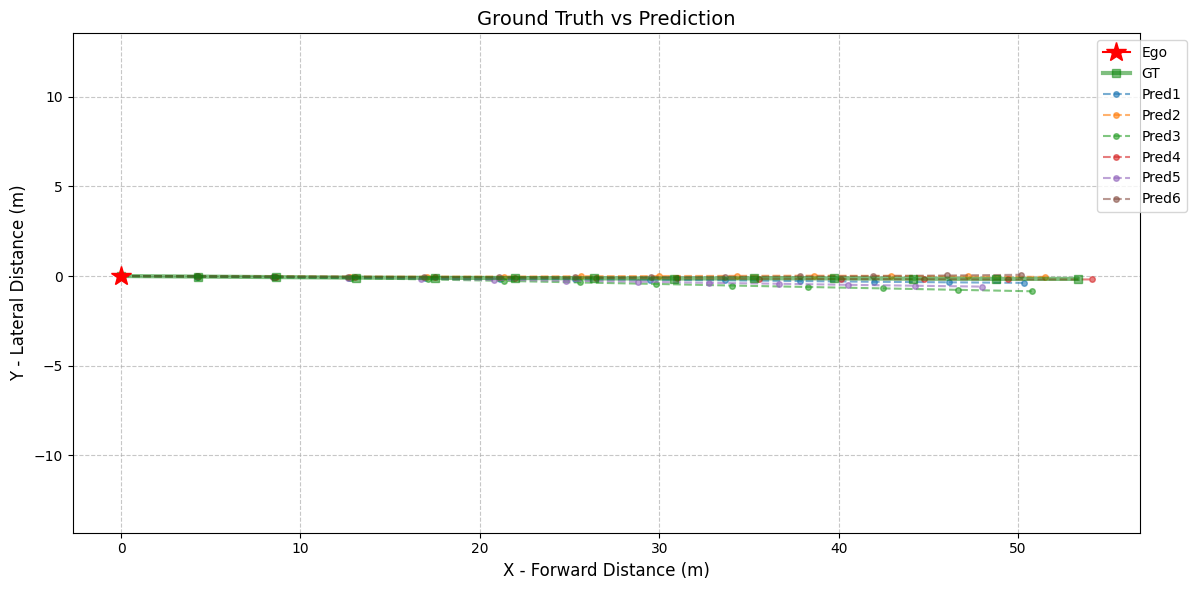

In [15]:
best_wp, gt_wp = plot_gt_and_pred(data['wp_future'], all_pred_waypoints)

## Rendering

**Note:** Running this section requires downloading the [nuScenes dataset](https://www.nuscenes.org/nuscenes#download).

In [ ]:
from utils.results_utils import project_wp_to_image
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version='v1.0-trainval', dataroot='/home/ximeng/Dataset/nuscenes_full_v1_0/', verbose=False) # dataroot is the path to the nuScenes dataset

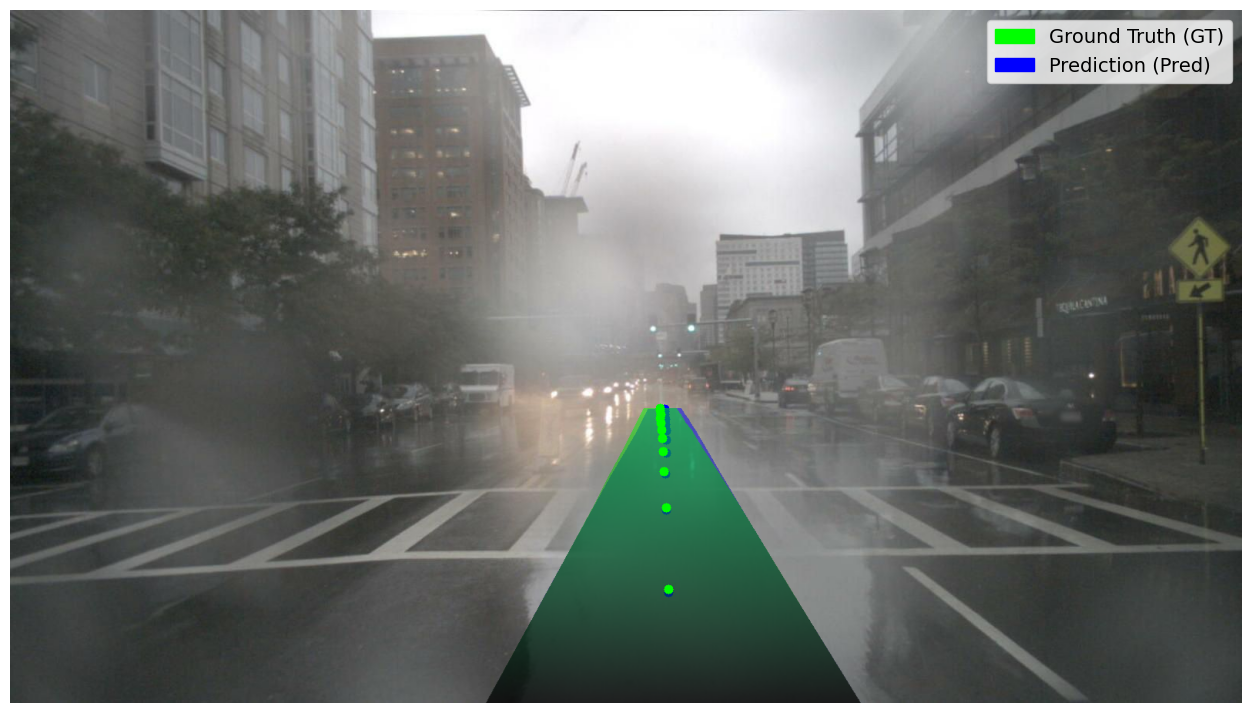

In [ ]:
token = data['token'][0]
img_np = np.array(images[3])
vis_img = project_wp_to_image(nusc, token, best_wp, img_np, color_waypoints=(0, 0, 255), color_polygon=(0, 0, 255))
vis_img = project_wp_to_image(nusc, token, gt_wp, vis_img, color_waypoints=(0, 255, 0), color_polygon=(0, 255, 0))
plt.figure(figsize=(16, 9))
gt_patch = mpatches.Patch(color=(0, 1, 0), label='Ground Truth (GT)')
pred_patch = mpatches.Patch(color=(0, 0, 1), label='Prediction (Pred)')
plt.legend(handles=[gt_patch, pred_patch], loc='upper right', fontsize=14, framealpha=0.8)
plt.axis('off')
plt.imshow(vis_img)

In [ ]:
print(reason)

Perception: The vehicle is moving straight on a wet urban road with moderate traffic. Rain is reducing visibility and affecting road traction. The front view shows cars ahead and a pedestrian crossing sign on the right. The surroundings include tall buildings, storefronts, and parked vehicles. No immediate obstacles or pedestrians are in the direct path, but road conditions require caution.

Action: Maintain current trajectory with slight deceleration to match reduced traction and visibility conditions. Increase following distance from the vehicle ahead.

Reasoning: Rain conditions increase stopping distance and reduce tire grip. Slowing down and increasing distance provides a safety buffer for potential sudden braking or skidding. The absence of immediate hazards justifies maintaining the straight path, but caution is warranted due to wet pavement and potential pedestrian activity near the crosswalk sign.
